In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("bank_marketing_dataset.csv")
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [3]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


In [7]:
print(df.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [8]:
X = df[["age", "job", "balance", "loan", "contact"]]
y = df["deposit"]


In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in ["job","loan","contact"]:
    X[col]=le.fit_transform(X[col])
y=le.fit_transform(y)


C:\Users\Srin\AppData\Local\Temp\ipykernel_17760\3185242146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]=le.fit_transform(X[col])
C:\Users\Srin\AppData\Local\Temp\ipykernel_17760\3185242146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]=le.fit_transform(X[col])
C:\Users\Srin\AppData\Local\Temp\ipykernel_17760\3185242146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [11]:
model=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

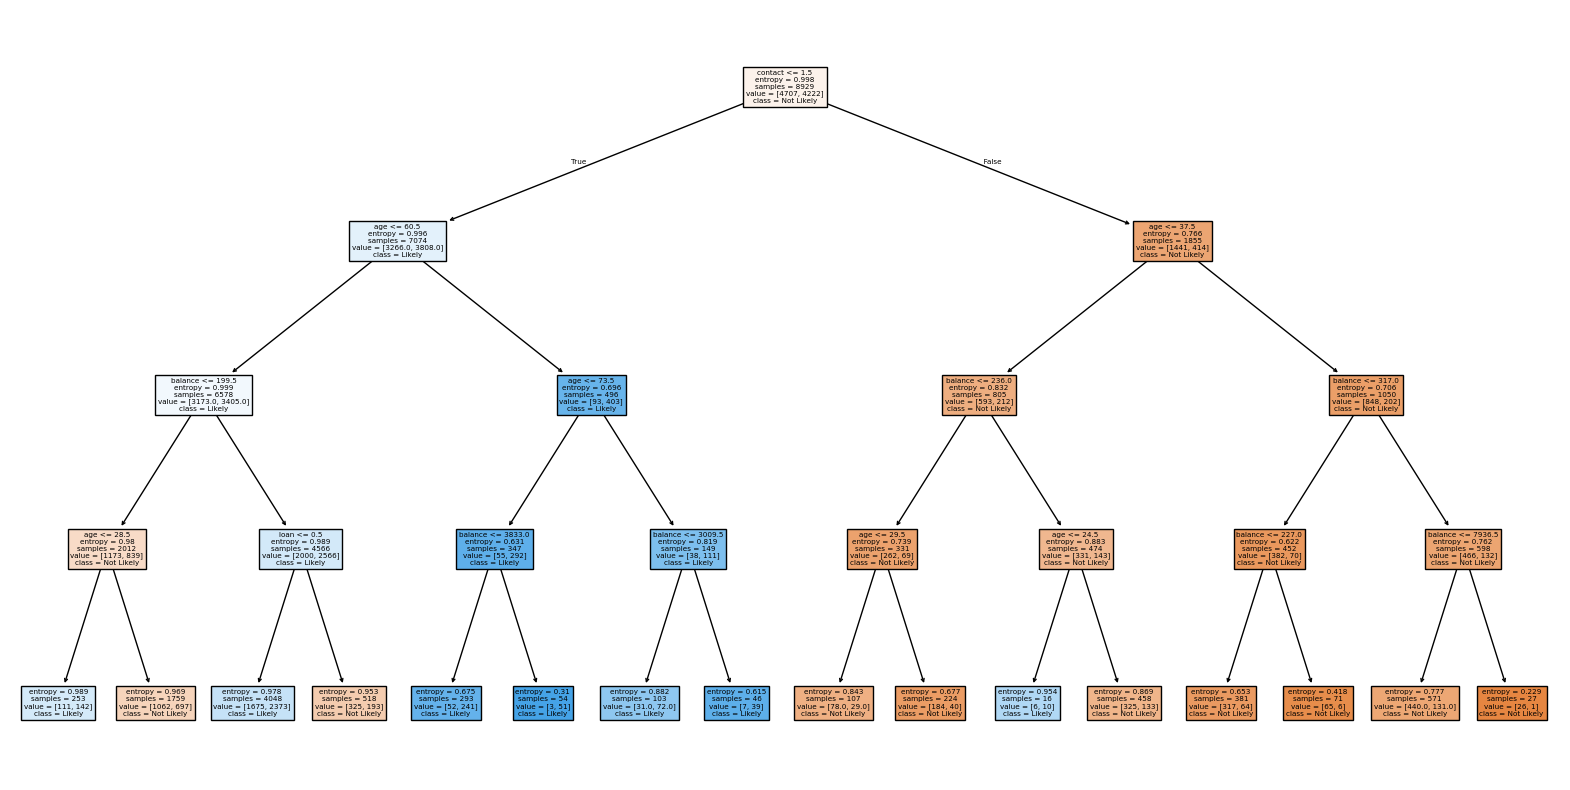

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Likely","Likely"],
    filled=True
)
plt.show()

In [16]:
y_pred = model.predict(X_test)


In [23]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)

0.658307210031348

In [18]:
confusion_matrix(y_test,y_pred)

array([[717, 449],
       [314, 753]])

In [19]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.70      0.61      0.65      1166\n           1       0.63      0.71      0.66      1067\n\n    accuracy                           0.66      2233\n   macro avg       0.66      0.66      0.66      2233\nweighted avg       0.66      0.66      0.66      2233\n'

In [20]:
prediction = model.predict(X_test)


In [21]:
if prediction[0] == 1:
    print("Likely to Subscribe")
else:
    print("Not Likely to Subscribe")


Likely to Subscribe


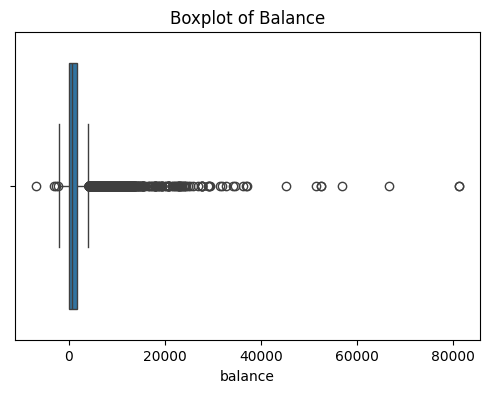

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x=df["balance"])
plt.title("Boxplot of Balance")
plt.show()


In [24]:
from sklearn.tree import export_text
rules=export_text(model,feature_names=list(X.columns))
print(rules)


|--- contact <= 1.50
|   |--- age <= 60.50
|   |   |--- balance <= 199.50
|   |   |   |--- age <= 28.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  28.50
|   |   |   |   |--- class: 0
|   |   |--- balance >  199.50
|   |   |   |--- loan <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- loan >  0.50
|   |   |   |   |--- class: 0
|   |--- age >  60.50
|   |   |--- age <= 73.50
|   |   |   |--- balance <= 3833.00
|   |   |   |   |--- class: 1
|   |   |   |--- balance >  3833.00
|   |   |   |   |--- class: 1
|   |   |--- age >  73.50
|   |   |   |--- balance <= 3009.50
|   |   |   |   |--- class: 1
|   |   |   |--- balance >  3009.50
|   |   |   |   |--- class: 1
|--- contact >  1.50
|   |--- age <= 37.50
|   |   |--- balance <= 236.00
|   |   |   |--- age <= 29.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  29.50
|   |   |   |   |--- class: 0
|   |   |--- balance >  236.00
|   |   |   |--- age <= 24.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  24.50
| 

In [25]:
top_feature_index=model.tree_.feature[0]
top_feature_name=X.columns[top_feature_index]
print("Top decision attribute ",top_feature_name)

Top decision attribute  contact


In [26]:
print("Tree Depth:", model.get_depth())


Tree Depth: 4


In [27]:
deep_model = DecisionTreeClassifier(random_state=42)
deep_model.fit(X_train, y_train)

print("Deep Tree Accuracy (Train):", deep_model.score(X_train, y_train))
print("Deep Tree Accuracy (Test):", deep_model.score(X_test, y_test))


Deep Tree Accuracy (Train): 0.9823048493672304
Deep Tree Accuracy (Test): 0.6023287057769816


In [28]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)


   Feature  Importance
4  contact    0.567468
0      age    0.211661
2  balance    0.143052
3     loan    0.077819
1      job    0.000000


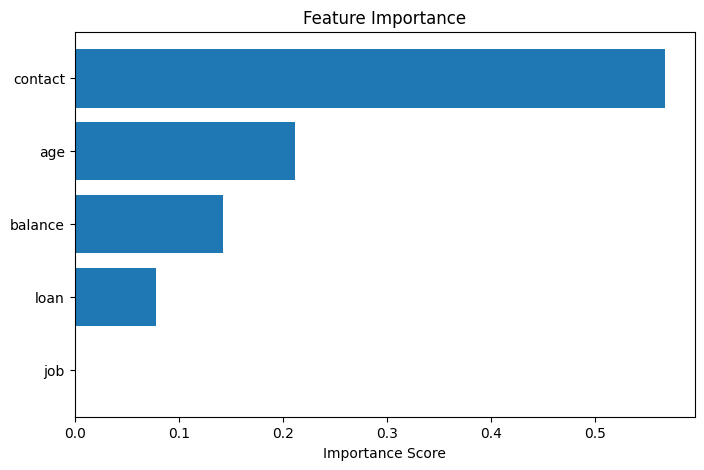

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()
